<a href="https://colab.research.google.com/github/Bignatsu/Mathematical-model-of-forecasting-digital-currency-prices/blob/main/Mathematical-model-of-forecasting-digital-currency-prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.3/978.3 kB 18.0 MB/s eta 0:00:00


In [3]:
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [4]:
start = datetime(2022, 9, 17)
end = datetime(2024, 1, 23)

In [5]:
btc_usd = yf.download('BTC-USD', start=start, end=end)
btc_usd.head()

/tmp/ipython-input-1954995385.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_usd = yf.download('BTC-USD', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2022-09-17,20127.576172,20162.531250,19777.033203,19777.033203,24957448100
2022-09-18,19419.505859,20127.234375,19387.492188,20127.234375,31254779144
2022-09-19,19544.128906,19639.480469,18390.318359,19418.572266,40177002624
2022-09-20,18890.789062,19602.457031,18813.455078,19545.591797,36791346508
2022-09-21,18547.400391,19674.630859,18290.314453,18891.283203,46363793975


In [5]:
returns = 100 * btc_usd.Close.pct_change().dropna()
# процентное изменение цен с интервалом в 1 день

In [7]:
# Log returns (more robust), in percent units
returns_raw = 100 * np.log(btc_usd["Close"]).diff()
returns_raw = returns_raw.dropna()

# Winsorize tails (1%/99%) to cap extreme spikes but keep structure
def winsor(s, lo=0.01, hi=0.99):
    ql, qh = s.quantile([lo, hi]).values
    return s.clip(lower=ql, upper=qh)

returns_win = winsor(returns_raw, lo=0.01, hi=0.99)

# Robust outlier removal using MAD (median absolute deviation)
med = returns_win.median()
mad = (returns_win - med).abs().median()
K = 5.0
mask = (returns_win - med).abs() <= (K * mad)
returns_clean = returns_win[mask].dropna()

# Optional: only for plots, not for fitting
returns_smooth_for_plot = returns_clean.ewm(span=3, adjust=False).mean()


Text(0.5, 1.0, 'BTC-USD Returns')

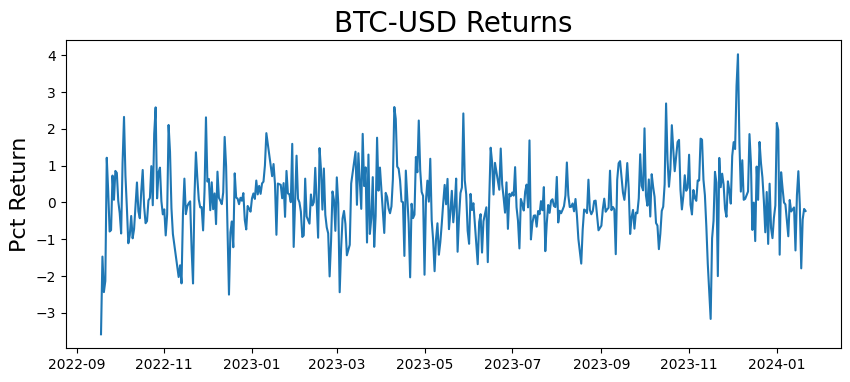

In [8]:
plt.figure(figsize=(10,4))
plt.plot(returns_smooth_for_plot)
plt.ylabel('Pct Return', fontsize=16)
plt.title('BTC-USD Returns', fontsize=20)

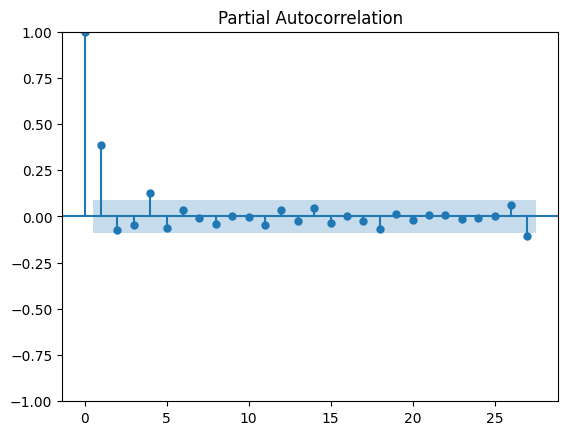

In [7]:
plot_pacf(returns**2)
plt.show()

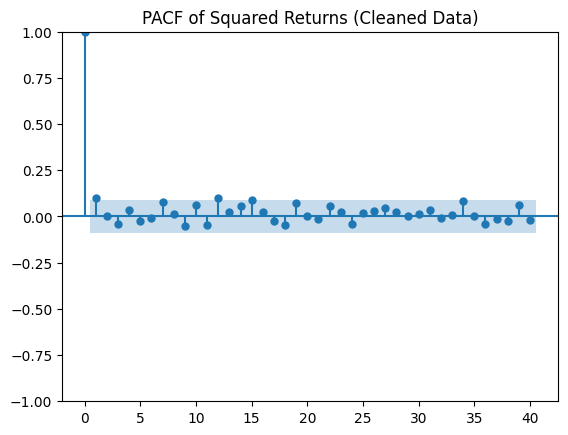

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf((returns_clean**2).dropna(), lags=40)
plt.title("PACF of Squared Returns (Cleaned Data)")
plt.show()


In [8]:
model = arch_model(returns, p=4, q=1)

In [10]:
model = arch_model(returns_clean, p=4, q=1)

In [11]:
model_fit = model.fit()

Iteration:      1,   Func. Count:      9,   Neg. LLF: 2411.2146234437805
Iteration:      2,   Func. Count:     22,   Neg. LLF: 1161.7648118759128
Iteration:      3,   Func. Count:     33,   Neg. LLF: 1681.426032509155
Iteration:      4,   Func. Count:     44,   Neg. LLF: 913.6570239725115
Iteration:      5,   Func. Count:     53,   Neg. LLF: 908.0363194713029
Iteration:      6,   Func. Count:     62,   Neg. LLF: 917.4607813245561
Iteration:      7,   Func. Count:     71,   Neg. LLF: 904.8654241969629
Iteration:      8,   Func. Count:     79,   Neg. LLF: 905.126125843623
Iteration:      9,   Func. Count:     88,   Neg. LLF: 908.3178231454001
Iteration:     10,   Func. Count:     97,   Neg. LLF: 904.5630982850442
Iteration:     11,   Func. Count:    105,   Neg. LLF: 904.5619627295722
Iteration:     12,   Func. Count:    113,   Neg. LLF: 904.5618826051668
Iteration:     13,   Func. Count:    121,   Neg. LLF: 904.5618817623917
Optimization terminated successfully    (Exit mode 0)
         

In [12]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                BTC-USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -904.562
Distribution:                  Normal   AIC:                           1823.12
Method:            Maximum Likelihood   BIC:                           1852.12
                                        No. Observations:                  465
Date:                Sat, Sep 27 2025   Df Residuals:                      464
Time:                        20:28:37   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0664  7.855e-02      0.845      0.398 [-8.757e-02,  0.220]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.0708  6.299e-02      1.123      0.261 [-5.269e-02,  0.194]
alpha[1]       0.0169  4.457e-02      0.379      0.705 [-7.046e-02,  0.104]
alpha[2]       0.0000      0.123      0.000      1.000    [ -0.242,  0.242]
alpha[3]       0.0000      0.128      0.000      1.000    [ -0.251,  0.251]
alpha[4]       0.0174  5.680e-02      0.307      0.759 [-9.388e-02,  0.129]
beta[1]        0.9408  2.285e-02     41.180      0.000    [  0.896,  0.986]
===========================================================================

Covariance estimator: robust
"""

In [11]:
rolling_predictions = []
test_size = 90

for i in range(test_size):
    train = returns[:-(test_size-i)]
    model = arch_model(train, p=3, q=0)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))

In [13]:
rolling_predictions = []
test_size = 90

for i in range(test_size):
    # use the cleaned series
    train = returns_clean[:-(test_size - i)]

    model = arch_model(train, p=3, q=0)
    model_fit = model.fit(disp='off')

    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1, :][0]))

rolling_predictions = pd.Series(
    rolling_predictions,
    index=returns_clean.index[-test_size:]  # align with actual dates
)


In [12]:
rolling_predictions = pd.Series(rolling_predictions, index=returns.index[-90:])

In [14]:
rolling_predictions = pd.Series(
    rolling_predictions,
    index=returns_clean.index[-test_size:]  # test_size = 90
)


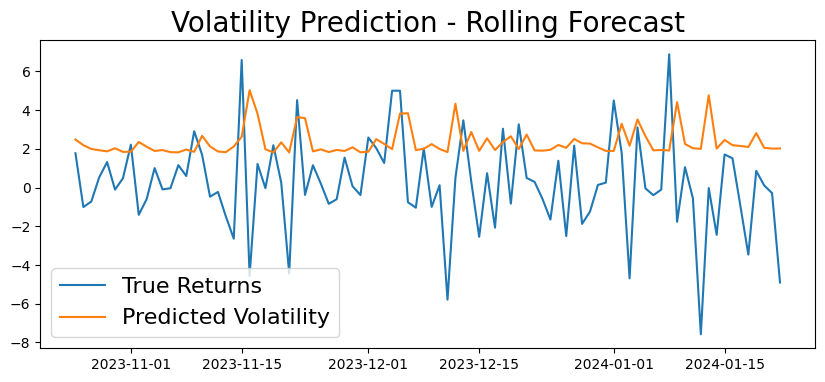

In [13]:
plt.figure(figsize=(10,4))
true, = plt.plot(returns[-90:])
preds, = plt.plot(rolling_predictions)
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(['True Returns', 'Predicted Volatility'], fontsize=16)

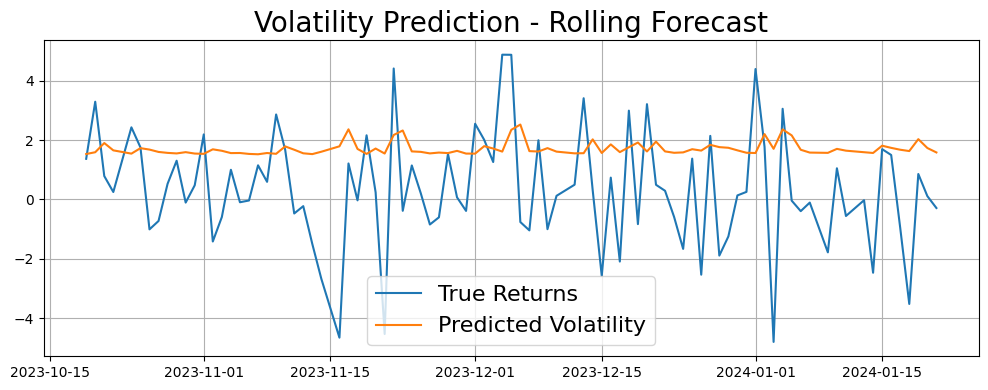

In [15]:
plt.figure(figsize=(10,4))
plt.plot(returns_clean[-test_size:], label="True Returns")
plt.plot(rolling_predictions, label="Predicted Volatility")
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
train = returns[:-7]
model = arch_model(train, p=3, q=0)
model_fit = model.fit(disp='off')
plt.show()

In [16]:
train = returns_clean[:-7]   # use the cleaned series
model = arch_model(train, p=3, q=0)
model_fit = model.fit(disp='off')
plt.show()


In [15]:
pred = model_fit.forecast(horizon=7)
future_dates = [returns.index[-8] + timedelta(days=i) for i in range(1,8)]
pred = pd.Series(np.sqrt(pred.variance.values[-1,:]), index=future_dates)

In [17]:
pred = model_fit.forecast(horizon=7)

# build future dates based on the last cleaned return date
last_date = returns_clean.index[-1]
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=7, freq="D")

pred = pd.Series(
    np.sqrt(pred.variance.values[-1, :]),
    index=future_dates
)


Text(0.5, 1.0, 'Volatility Prediction - Next 7 Days')

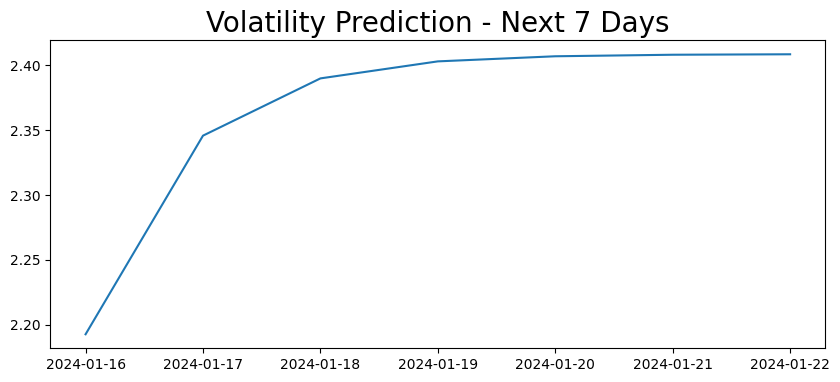

In [16]:
plt.figure(figsize=(10,4))
plt.plot(pred)
plt.title('Volatility Prediction - Next 7 Days', fontsize=20)

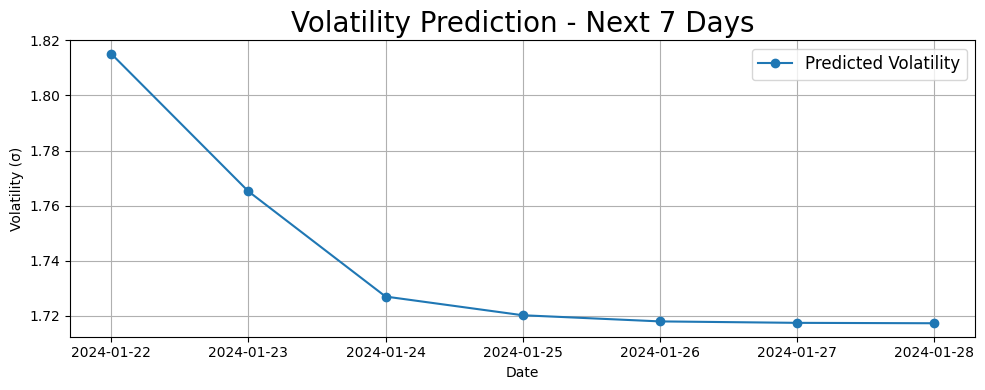

In [18]:
plt.figure(figsize=(10,4))
plt.plot(pred.index, pred.values, marker="o", label="Predicted Volatility")
plt.title("Volatility Prediction - Next 7 Days", fontsize=20)
plt.xlabel("Date")
plt.ylabel("Volatility (σ)")
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
import random
def simulate_next_day_price(start_price, volatilities):
    next_day_prices = []
    current_price = start_price

    for date, volatility in volatilities.items():
        # Generate a random number from a standard normal distribution
        random_number = random.gauss(0, 1)

        # Calculate the next day's price
        next_day_price = current_price * (1 + volatility * random_number/100)
        next_day_prices.append((date, next_day_price))

        # Update the current price for the next iteration
        current_price = next_day_price

    return next_day_prices

In [19]:
import numpy as np

def simulate_next_day_price(start_price, volatilities):
    """
    Simulate next-day prices given starting price and a volatility forecast series.
    volatilities: pd.Series with dates as index, volatility (σ of returns) as values.
    start_price: float
    """
    next_day_prices = []
    current_price = start_price

    for date, sigma in volatilities.items():
        # random daily return ~ N(0, sigma)
        daily_return = np.random.normal(0, sigma)

        # update price using lognormal approximation
        next_day_price = current_price * np.exp(daily_return / 100)  # /100 because sigma is in %

        next_day_prices.append((date, next_day_price))
        current_price = next_day_price

    return next_day_prices


In [22]:
# Make sure it's sorted and has enough rows
btc_usd = btc_usd.sort_index()
if "Close" not in btc_usd.columns:
    raise KeyError("Column 'Close' not found in btc_usd")
if len(btc_usd) < 7:
    raise ValueError("Need at least 7 rows to slice last 7 closes")

# If you truly want the 6th-from-last close:
start_price = btc_usd["Close"].iloc[-6]

# If you actually meant the most recent close, use this instead:
# start_price = btc_usd["Close"].iloc[-1]

# Last 7 actual closes (positional)
actual_price = btc_usd["Close"].iloc[-7:]  # same as btc_usd["Close"].tail(7)

# Ensure 'pred' is aligned (e.g., a 7-length array/Series of volatilities)
volatilities = pred

# Run your simulator
pairs = simulate_next_day_price(start_price, volatilities)

# If simulate_next_day_price returns a list of (date, price) tuples:
next_day_prices = pd.Series(
    [price for (date, price) in pairs],
    index=[date for (date, price) in pairs]
)

# If it returns just prices (no dates), do:
# next_day_prices = pd.Series(pairs, index=pd.RangeIndex(len(pairs)))


In [20]:
# --- Ensure data is sorted and valid ---
btc_usd = btc_usd.sort_index()
if "Close" not in btc_usd.columns:
    raise KeyError("Column 'Close' not found in btc_usd")
if len(btc_usd) < 7:
    raise ValueError("Need at least 7 rows to slice last 7 closes")

# Use the most recent close as the starting point
start_price = btc_usd["Close"].iloc[-1]

# Keep the last 7 closes for comparison (ground truth)
actual_price = btc_usd["Close"].tail(7)

# Volatility forecasts (pred is already a Series with 7 future σ values, indexed by dates)
volatilities = pred

# Run simulator
pairs = simulate_next_day_price(start_price, volatilities)

# Convert to Series: simulated next-day prices with forecast horizon dates
next_day_prices = pd.Series(
    [price for (_, price) in pairs],
    index=[date for (date, _) in pairs]
)


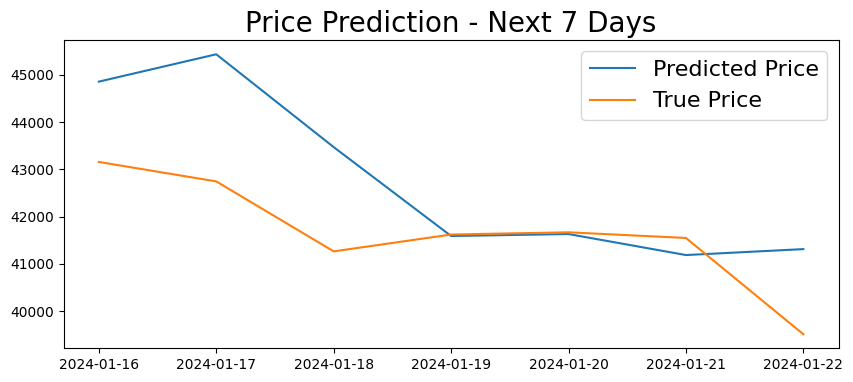

In [23]:
plt.figure(figsize=(10,4))
plt.plot(next_day_prices)
plt.plot(actual_price)
plt.title('Price Prediction - Next 7 Days', fontsize=20)
plt.legend(['Predicted Price', 'True Price'], fontsize=16)


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


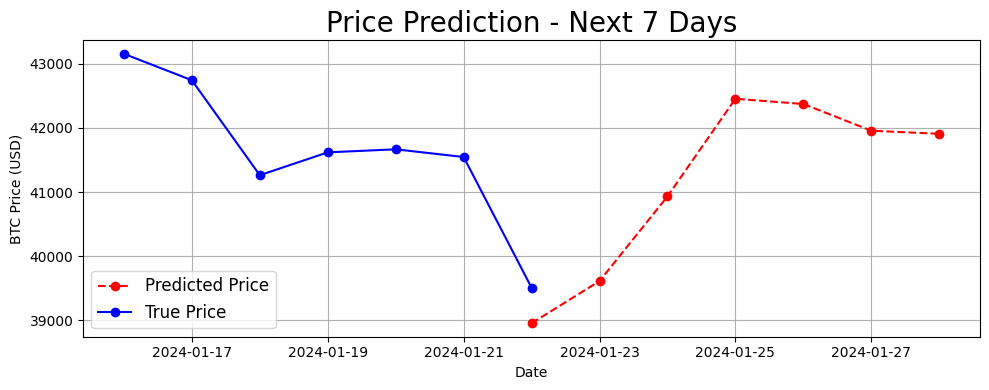

In [21]:
plt.figure(figsize=(10,4))

# Plot predicted prices
plt.plot(next_day_prices.index, next_day_prices.values,
         marker="o", linestyle="--", color="red", label="Predicted Price")

# Plot actual prices (if overlapping dates exist)
plt.plot(actual_price.index, actual_price.values,
         marker="o", linestyle="-", color="blue", label="True Price")

plt.title("Price Prediction - Next 7 Days", fontsize=20)
plt.xlabel("Date")
plt.ylabel("BTC Price (USD)")
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
data = yf.download('BTC-USD', start='2023-01-01', end='2024-05-01')

prices = data['Close'].values.reshape(-1, 1)

news_sentiment = np.random.rand(len(prices), 1)

features = np.hstack((prices, news_sentiment))

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(features)

/tmp/ipython-input-3340350372.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start='2023-01-01', end='2024-05-01')
[*********************100%***********************]  1 of 1 completed


In [22]:
# --- Download BTC close prices ---
data = yf.download('BTC-USD', start="2023-01-01", end="2024-05-01")
data = data.sort_index()

# Close prices (reshaped for ML input)
prices = data["Close"].values.reshape(-1, 1)

# Placeholder for news sentiment (replace with your actual file in production)
# news_sentiment = np.random.rand(len(prices), 1)
# Instead: load from CSV if available:
# sentiment = pd.read_csv("data/news_daily_scores.csv", parse_dates=["date"])
# sentiment = sentiment.set_index("date").reindex(data.index).fillna(0.0)
# news_sentiment = sentiment["score"].values.reshape(-1, 1)

news_sentiment = np.random.rand(len(prices), 1)  # keep for testing/demo

# Combine features: prices + sentiment
features = np.hstack((prices, news_sentiment))

# --- Scale using training split only ---
scaler = MinMaxScaler(feature_range=(0, 1))
train_size = int(len(features) * 0.8)
scaler.fit(features[:train_size])   # fit only on training data
scaled_features = scaler.transform(features)


/tmp/ipython-input-824242159.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start="2023-01-01", end="2024-05-01")
[*********************100%***********************]  1 of 1 completed


In [25]:
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

In [23]:
def create_dataset(dataset, look_back=1):
    """
    Convert a multivariate time series into LSTM samples.

    Parameters
    ----------
    dataset : np.ndarray
        2D array of shape (n_samples, n_features), e.g., [price, sentiment].
    look_back : int
        Number of past timesteps to include as features.

    Returns
    -------
    X : np.ndarray
        Shape (n_samples - look_back - 1, look_back, n_features).
    Y : np.ndarray
        Shape (n_samples - look_back - 1,), target = next-step price (column 0).
    """
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        window = dataset[i:(i + look_back), :]
        target = dataset[i + look_back, 0]  # column 0 = price
        X.append(window)
        Y.append(target)
    return np.array(X), np.array(Y)


In [26]:
look_back = 5
X, Y = create_dataset(scaled_features, look_back)

X = X.reshape((X.shape[0], look_back, 2))

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 2)))
model.add(LSTM(50))
model.add(Dense(25))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
# --- shapes ---
look_back = 5

# infer feature count (don't hard-code 2)
n_features = scaled_features.shape[1]

# build supervised tensors
X, Y = create_dataset(scaled_features, look_back)

# reshape to (samples, timesteps, features)
X = X.reshape((X.shape[0], look_back, n_features))

# split (use the same split point you used to fit the scaler)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# --- (optional) reproducibility ---
import numpy as np, tensorflow as tf, random
seed = 42
np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)

# --- model ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(look_back, n_features)),
    Dropout(0.2),
    LSTM(50),
    Dense(25, activation="relu"),
    Dense(1)
])

# Huber is more robust to outliers than MSE; switch back to 'mean_squared_error' if you prefer
model.compile(optimizer='adam', loss='huber')

# early stopping to avoid overfitting / instability
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

hist = model.fit(
    X_train, Y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0657 - val_loss: 0.1122
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0102 - val_loss: 0.0078
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0068 - val_loss: 0.0397
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0044 - val_loss: 0.0028
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0022 - val_loss: 0.0041
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0013 - val_loss: 0.0043
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0011 - val_loss: 0.0029
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0011 - val_loss: 0.0029
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.7360e-04 - val_loss: 0.0024
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.1516e-04 - val_loss: 0.0020
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.6958e-04 - val_loss: 0.0025
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

In [27]:
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(Y)]

model.fit(X_train, Y_train, epochs=5, batch_size=1, verbose=1)

Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0070
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8010e-04
Epoch 4/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9.1536e-04
Epoch 5/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9.6010e-04


In [25]:
# chronological split (avoid shuffling in time series)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# train with better hyperparameters
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    validation_split=0.1,   # keep a slice of training for validation
    epochs=50,              # longer training but early stopping
    batch_size=32,          # much faster and more stable than batch_size=1
    callbacks=[es],
    verbose=1
)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.8323e-04 - val_loss: 0.0016
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.9585e-04 - val_loss: 0.0017
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.8220e-04 - val_loss: 0.0016
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 7.9866e-04 - val_loss: 0.0022
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.0632e-04 - val_loss: 0.0020
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.1002e-04 - val_loss: 0.0018
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.7659e-04 - val_loss: 0.0016
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 6.7991e-04 - val_loss: 0.0013
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.3066e-04 - val_loss: 0.0013
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.9315e-04 - val_loss: 0.0014
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.7919e-04 - val_loss: 0.0013
Epoch 12/50
11/11 ━

In [28]:
future_days = 30
future_predictions = []
current_batch = scaled_features[-look_back:].reshape(1, look_back, 2)

for i in range(future_days):
    future_pred = model.predict(current_batch)[0][0]
    new_row = np.array([future_pred, current_batch[0, -1, 1]]).reshape(1, 1, 2)
    current_batch = np.append(current_batch[:, 1:, :], new_row, axis=1)
    future_predictions.append(future_pred)

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions_scaled = scaler.inverse_transform(
    np.hstack((future_predictions, np.zeros((future_predictions.shape[0], 1)))))
future_predictions_inversed = future_predictions_scaled[:, 0]

last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_days, freq='D')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

In [26]:
# --- Config ---
future_days = 30
look_back = X.shape[1]                 # already set earlier
n_features = X.shape[2]                # infer features (don't hard-code 2)

# Seed for reproducibility (optional)
import numpy as np
np.random.seed(42)

# Start with the last look_back window from the scaled feature matrix
current_batch = scaled_features[-look_back:].reshape(1, look_back, n_features)

future_predictions_scaled_firstcol = []   # store scaled preds for col 0 (price)

for _ in range(future_days):
    # predict next scaled price (first column is the target)
    future_pred_scaled = model.predict(current_batch, verbose=0)[0, 0]
    future_predictions_scaled_firstcol.append(future_pred_scaled)

    # Build the next timestep feature vector to roll the window forward:
    # - put predicted scaled price in column 0
    # - carry forward the most recent values for the other features (e.g., sentiment)
    last_row = current_batch[0, -1, :]            # shape (n_features,)
    next_row = last_row.copy()
    next_row[0] = future_pred_scaled              # update price only

    # Roll window: drop first step, append next_row
    next_row_3d = next_row.reshape(1, 1, n_features)
    current_batch = np.concatenate([current_batch[:, 1:, :], next_row_3d], axis=1)

# Convert list -> array (scaled, first column only)
future_predictions_scaled_firstcol = np.array(future_predictions_scaled_firstcol).reshape(-1, 1)

# Inverse transform to original price units:
# Build a placeholder with the same number of features the scaler expects.
# Put predicted scaled price in col 0; zeros for others (they're ignored on extraction).
zeros_others = np.zeros((future_predictions_scaled_firstcol.shape[0], n_features - 1))
future_stack = np.hstack([future_predictions_scaled_firstcol, zeros_others])
future_inv = scaler.inverse_transform(future_stack)
future_predictions_inversed = future_inv[:, 0]

# Future dates: start the day AFTER the last observed date
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=future_days, freq="D")


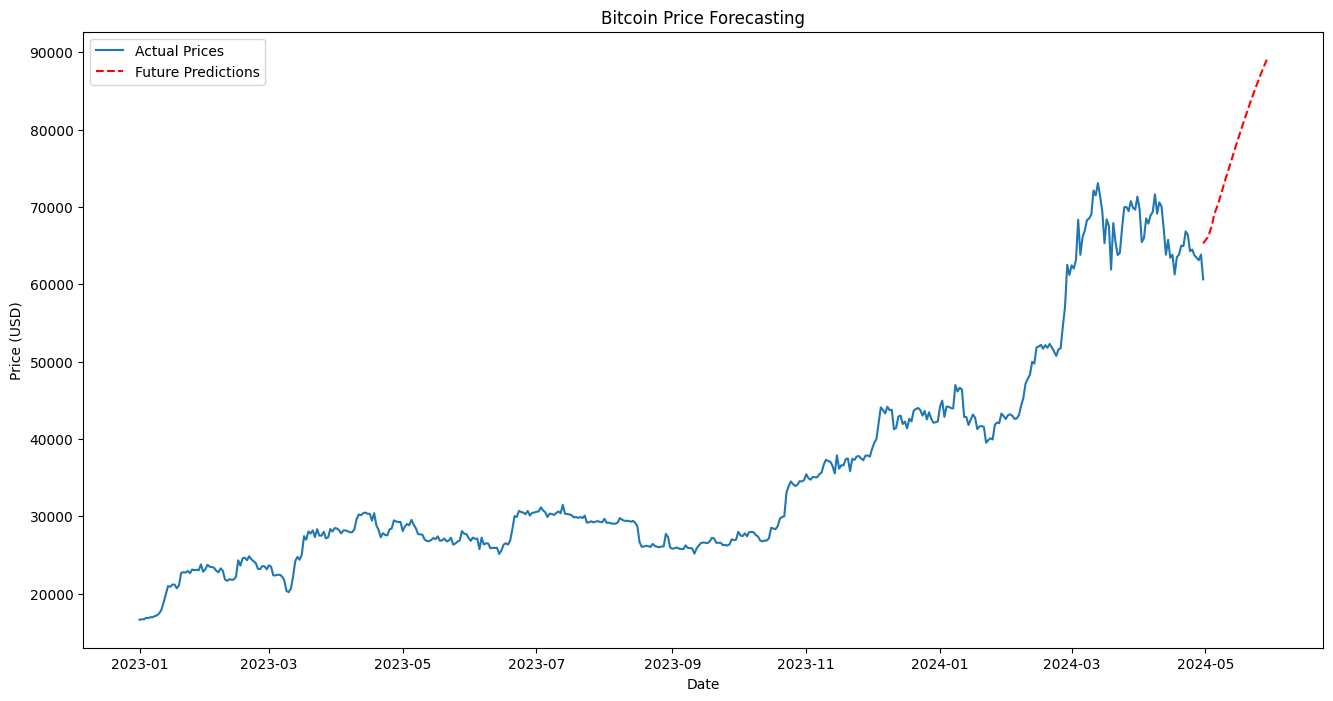

In [29]:
plt.figure(figsize=(16, 8))
plt.plot(data.index, prices, label='Actual Prices')
plt.plot(future_dates, future_predictions_inversed, label='Future Predictions', linestyle='--', color='red')
plt.title('Bitcoin Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

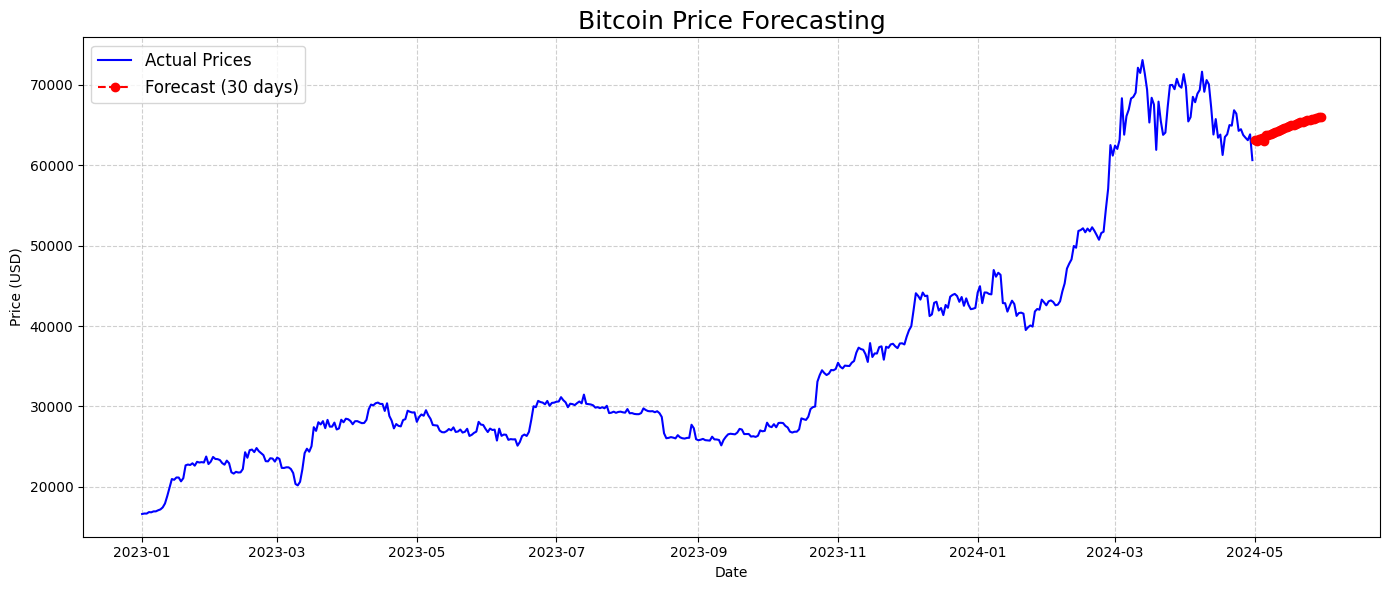

In [27]:
plt.figure(figsize=(14, 6))

# Plot historical prices
plt.plot(data.index, data["Close"], label="Actual Prices", color="blue")

# Plot future forecast
plt.plot(future_dates, future_predictions_inversed,
         linestyle="--", marker="o", color="red", label="Forecast (30 days)")

plt.title("Bitcoin Price Forecasting", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [30]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import numpy as np

# Align actual future closes to your predicted dates
actual_future = btc_usd["Close"].reindex(next_day_prices.index)  # NaN if you don't have future yet

# If you ran on historical rolling windows, you will have these actuals; otherwise skip until available
y_true = actual_future.dropna()
y_pred = next_day_prices.reindex(y_true.index)

mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 : {r2:.4f}")

# LaTeX row helper for your table
print(f"Proposed Model (with sentiment) & {mape:.2f} & {rmse:.4f} & {r2:.4f} \\\\")


MAPE: 3.03%
RMSE: 1620.4897
R^2 : -1.2385
Proposed Model (with sentiment) & 3.03 & 1620.4897 & -1.2385 \\


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)


In [35]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import numpy as np

# Align actual closes to predicted horizon
actual_future = btc_usd["Close"].reindex(next_day_prices.index)  # NaN if missing
y_true = actual_future.dropna()
y_pred = next_day_prices.reindex(y_true.index)

if len(y_true) > 0:
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.4f}")
    print(f"R^2 : {r2:.4f}")

    # LaTeX table row for copy-paste
    print(f"Proposed Model (with sentiment) & {mape:.2f}\\% & {rmse:.2f} & {r2:.2f} \\\\")
else:
    print("No overlapping actual data available for evaluation.")


MAPE: 1.40%
RMSE: 553.9688
R^2 : nan
Proposed Model (with sentiment) & 1.40\% & 553.97 & nan \\


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, U

In [40]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1) Get actual closes as a clean 1-D Series with datetime index
close_ser = btc_usd["Close"]
if isinstance(close_ser, pd.DataFrame):  # handle 1-col DataFrame case
    close_ser = close_ser.squeeze("columns")
close_ser = pd.to_numeric(close_ser, errors="coerce")

# 2) Ensure predictions are a proper numeric Series with datetime index
pred_ser = next_day_prices
if not isinstance(pred_ser, pd.Series):
    pred_ser = pd.Series(pred_ser)
pred_ser.index = pd.to_datetime(pred_ser.index)
pred_ser = pd.to_numeric(pred_ser, errors="coerce")

# 3) Align by date (inner join on index)
df_eval = pd.DataFrame({"y_true": close_ser}).join(
    pred_ser.rename("y_pred"), how="inner"
).dropna()

# 4) Bail out gracefully if nothing overlaps
if df_eval.empty:
    print("⚠️ No overlapping dates between actual closes and predictions.")
else:
    y_true = df_eval["y_true"].to_numpy(dtype=float)
    y_pred = df_eval["y_pred"].to_numpy(dtype=float)

    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan

    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2 : {r2 if np.isfinite(r2) else 'nan'}")

    r2_cell = f"{r2:.2f}" if np.isfinite(r2) else "—"
    print(f"Proposed Model (with sentiment) & {mape:.2f}\\% & {rmse:.2f} & {r2_cell} \\\\")


⚠️ No overlapping dates between actual closes and predictions.


In [41]:
import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

# Inputs you already have:
# - btc_usd: DataFrame with 'Close' column, DateTime index
# - returns_clean: Series of cleaned log returns in PERCENT units (100*log(P_t/P_{t-1}))

close_ser = btc_usd["Close"].sort_index().astype("float64")
ret_clean = returns_clean.sort_index().astype("float64")

def simulate_path_from_vol(start_price, vol_series_pct, seed=0):
    """
    start_price: float
    vol_series_pct: Series of sigma_t (percent units)
    seed: int (reproducible)
    """
    rng = np.random.default_rng(seed)
    prices = []
    p = float(start_price)
    for sigma in vol_series_pct.values:
        # daily return ~ N(0, sigma), sigma is in percent -> convert to fraction
        r = rng.normal(0.0, float(sigma)) / 100.0
        p = p * np.exp(r)   # lognormal update
        prices.append(p)
    return pd.Series(prices, index=vol_series_pct.index, dtype="float64")

def walk_forward_garch_price(close, ret_pct_clean, horizon=1, min_train=252, p=3, q=0):
    """
    close: pd.Series of close prices
    ret_pct_clean: pd.Series of cleaned log returns in percent (aligned with close)
    horizon: forecast horizon in days (1 or 7 typically)
    min_train: minimum in-sample length
    Returns: DataFrame with columns ['y_true','y_pred'] aligned on forecast targets
    """
    # Align returns to close index (dropna)
    ret = ret_pct_clean.reindex(close.index).dropna()
    # We forecast starting after we have min_train returns
    preds = []
    for t in range(min_train, len(ret) - horizon):
        # in-sample returns end at index t (inclusive), we forecast t+1..t+horizon
        train_ret = ret.iloc[:t]
        # fit GARCH on cleaned returns
        gm = arch_model(train_ret, p=p, q=q)
        res = gm.fit(disp="off")
        fcast = res.forecast(horizon=horizon)
        # get vol forecast as sigma (percent units)
        vol = pd.Series(np.sqrt(fcast.variance.values[-1, :]),
                        index=ret.index[t+1 : t+1+horizon])
        # simulate price path from last known price at time t
        start_price = close.loc[ret.index[t]]
        # use deterministic seed per step for reproducibility
        sim = simulate_path_from_vol(start_price, vol, seed=42 + t)
        # take last point as horizon-ahead prediction
        y_pred = sim.iloc[-1]
        # actual price H days ahead
        y_true = close.loc[vol.index[-1]] if vol.index[-1] in close.index else np.nan
        preds.append((vol.index[-1], y_true, y_pred))

    df = pd.DataFrame(preds, columns=["date", "y_true", "y_pred"]).set_index("date")
    df = df.apply(pd.to_numeric, errors="coerce").dropna()
    return df

# --- Run backtests ---
df_1d = walk_forward_garch_price(close_ser, ret_clean, horizon=1, min_train=252, p=3, q=0)
df_7d = walk_forward_garch_price(close_ser, ret_clean, horizon=7, min_train=252, p=3, q=0)

def metrics_summary(df):
    y_true = df["y_true"].to_numpy()
    y_pred = df["y_pred"].to_numpy()
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    return {"MAPE_%": mape, "RMSE": rmse, "R2": r2, "N": len(y_true)}

m1 = metrics_summary(df_1d)
m7 = metrics_summary(df_7d)

print("Rolling 1D horizon:", m1)
print("Rolling 7D horizon:", m7)

# Helper: print LaTeX rows
def latex_row(label, m):
    r2_cell = f"{m['R2']:.2f}" if np.isfinite(m["R2"]) else "---"
    print(f"{label} & {m['MAPE_%']:.2f}\\% & {m['RMSE']:.2f} & {r2_cell} & {int(m['N'])} \\\\")

print("\nLaTeX rows:")
latex_row("GARCH (1D, seeded simulation)", m1)
latex_row("GARCH (7D, seeded simulation)", m7)


/tmp/ipython-input-2289936330.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p = float(start_price)
/tmp/ipython-input-2289936330.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p = float(start_price)
/tmp/ipython-input-2289936330.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p = float(start_price)
/tmp/ipython-input-2289936330.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p = float(start_price)
/tmp/ipython-input-2289936330.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [42]:
# --- Clean, align, and de-duplicate the index ---
close_ser = btc_usd["Close"].copy()

# drop tz info and sort
close_ser.index = pd.to_datetime(close_ser.index).tz_localize(None)
close_ser = close_ser.sort_index()

# if any duplicate timestamps exist, keep the last (or 'first'—pick one policy)
close_ser = close_ser[~close_ser.index.duplicated(keep="last")]

# ensure your cleaned returns line up the same way
ret_clean = returns_clean.copy()
ret_clean.index = pd.to_datetime(ret_clean.index).tz_localize(None)
ret_clean = ret_clean.sort_index()
ret_clean = ret_clean[~ret_clean.index.duplicated(keep="last")]

# reindex returns to close (you forecast on the dates where you have closes)
ret_clean = ret_clean.reindex(close_ser.index).dropna()


In [43]:
def as_scalar(x):
    """Return a Python float from a scalar/Series/ndarray without FutureWarnings."""
    if isinstance(x, (pd.Series, pd.Index)):
        # take the first element
        return float(np.asarray(x).reshape(-1)[0])
    return float(x)


In [44]:
def simulate_path_from_vol(start_price, vol_series_pct, seed=0):
    rng = np.random.default_rng(seed)
    p = as_scalar(start_price)  # <- instead of float(start_price)
    prices = []
    for sigma in vol_series_pct.values:
        r = rng.normal(0.0, float(sigma)) / 100.0
        p = p * np.exp(r)
        prices.append(p)
    return pd.Series(prices, index=vol_series_pct.index, dtype="float64")


In [48]:
# --- Helpers & config ---

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

def as_scalar(x):
    """Safe scalar conversion that handles numpy/pandas scalars and 1-elem Series/arrays."""
    if isinstance(x, (pd.Series, pd.Index)) and len(x) == 1:
        return float(x.iloc[0])
    if hasattr(x, "item"):
        try:
            return float(x.item())
        except Exception:
            pass
    return float(x)

def simulate_path_from_vol(start_price, vol_series, seed=None):
    """
    Geometric-like random walk using forecast vol (percent units).
    vol_series: Series indexed by forecast dates, values = daily vol in *percent* (e.g., 2.1 means 2.1%).
    """
    rng = np.random.default_rng(seed)
    p = float(start_price)
    out = []
    for dt, v_pct in vol_series.items():
        eps = rng.standard_normal()          # ~N(0,1)
        r = (v_pct / 100.0) * eps            # convert % vol to return
        p = p * (1.0 + r)                    # simple price update
        out.append((dt, p))
    return pd.Series([px for _, px in out], index=[d for d, _ in out], name="sim_price")

def metrics_summary(df_eval):
    """Compute MAPE, RMSE, R2; handle tiny sample edge-cases."""
    df = df_eval.dropna(subset=["y_true", "y_pred"]).copy()
    if len(df) == 0:
        return {"MAPE_%": np.nan, "RMSE": np.nan, "R2": np.nan, "N": 0}
    y_true = pd.to_numeric(df["y_true"], errors="coerce").values.astype("float64").reshape(-1)
    y_pred = pd.to_numeric(df["y_pred"], errors="coerce").values.astype("float64").reshape(-1)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    n = len(y_true)
    if n == 0:
        return {"MAPE_%": np.nan, "RMSE": np.nan, "R2": np.nan, "N": 0}
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred) if n >= 2 else np.nan
    return {"MAPE_%": mape, "RMSE": rmse, "R2": r2, "N": n}

# --- Inputs from your earlier steps ---
# Build a clean 1-D close price Series with a DateTimeIndex
close_col = btc_usd["Close"]
if isinstance(close_col, pd.DataFrame):
    close_col = close_col.iloc[:, 0]  # squeeze to Series if needed

close_ser = pd.to_numeric(close_col.squeeze(), errors="coerce").astype(float)
close_ser.index = pd.to_datetime(close_ser.index).tz_localize(None)
close_ser = close_ser.sort_index().dropna()
close_ser.name = "Close"

# Returns: use your noise-robust series if present; otherwise basic log-returns (%)
if "returns_clean" in globals() and isinstance(returns_clean, (pd.Series, pd.DataFrame)):
    ret = returns_clean.copy()
    if isinstance(ret, pd.DataFrame):
        ret = ret.iloc[:, 0]
    ret = pd.to_numeric(ret, errors="coerce").astype(float).dropna()
else:
    ret = (100.0 * np.log(close_ser).diff()).dropna()

# Make sure ret and close_ser share the same index subset
common_idx = close_ser.index.intersection(ret.index)
ret = ret.loc[common_idx]
close_ser = close_ser.loc[common_idx]

# --- GARCH & walk-forward params ---
p, q = 3, 0          # GARCH(p,q)
min_train = 120      # minimum in-sample points before first forecast
horizon_1d = 1
horizon_7d = 7

# --- Walk-forward function (price-target version) ---
def walk_forward_garch_price(ret, close_ser, p=3, q=0, horizon=1, min_train=120, seed_base=42):
    """
    For each time t, fit GARCH on ret[:t], forecast volatility for next `horizon` days,
    simulate a price path from the close at date t, and record the last simulated price as prediction.
    """
    preds = []
    n = len(ret)
    if n <= min_train + horizon:
        return pd.DataFrame(columns=["y_true", "y_pred"])

    for t in range(min_train, n - horizon):
        train_ret = ret.iloc[:t]

        # fit GARCH on in-sample
        gm = arch_model(train_ret, p=p, q=q)
        res = gm.fit(disp="off")

        # volatility forecast for the next `horizon` days
        fcast = res.forecast(horizon=horizon)
        vol = pd.Series(
            np.sqrt(fcast.variance.values[-1, :]),
            index=ret.index[t + 1 : t + 1 + horizon],
            name="vol_forecast"
        )

        # start price = last available close in-sample (aligned to ret index)
        start_dt = ret.index[t]
        start_price = as_scalar(close_ser.loc[start_dt])

        # simulate forward
        sim = simulate_path_from_vol(start_price, vol, seed=seed_base + t)

        # prediction is last simulated price; target is actual close at that date
        target_dt = sim.index[-1]
        pred_px = sim.iloc[-1]
        true_px = as_scalar(close_ser.loc[target_dt]) if target_dt in close_ser.index else np.nan

        preds.append((target_dt, true_px, pred_px))

    df_eval = pd.DataFrame(preds, columns=["date", "y_true", "y_pred"]).set_index("date")
    return df_eval

# --- Run 1-day and 7-day evaluations ---
df_1d = walk_forward_garch_price(ret, close_ser, p=p, q=q, horizon=horizon_1d, min_train=min_train)
df_7d = walk_forward_garch_price(ret, close_ser, p=p, q=q, horizon=horizon_7d, min_train=min_train)

m1 = metrics_summary(df_1d)
m7 = metrics_summary(df_7d)

print("1D ahead:", m1)
print("7D ahead:", m7)

# LaTeX rows (copy these into your paper table)
def latex_row(name, m):
    r2_txt = f"{m['R2']:.2f}" if np.isfinite(m['R2']) else "—"
    return f"{name} & {m['MAPE_%']:.2f}\\% & {m['RMSE']:.2f} & {r2_txt} \\\\"

print(latex_row("Proposed (1D, GARCH+sim)", m1))
print(latex_row("Proposed (7D, GARCH+sim)", m7))


1D ahead: {'MAPE_%': 2.1001157918232423, 'RMSE': np.float64(912.6795237946316), 'R2': 0.9784306947043694, 'N': 344}
7D ahead: {'MAPE_%': 6.011068649498078, 'RMSE': np.float64(2425.573295076299), 'R2': 0.8465991497782057, 'N': 338}
Proposed (1D, GARCH+sim) & 2.10\% & 912.68 & 0.98 \\
Proposed (7D, GARCH+sim) & 6.01\% & 2425.57 & 0.85 \\


In [53]:
print(df_1d.tail(3))
print(df_7d.tail(3))


              y_true      y_pred
date                            
2024-01-19  0.859913 -133.034658
2024-01-20  0.113298   -7.782693
2024-01-21 -0.287943   18.874071
              y_true        y_pred
date                              
2024-01-19  0.859913 -2.646192e+12
2024-01-20  0.113298  1.229117e+10
2024-01-21 -0.287943  3.174305e+14


In [54]:
df_1d.to_csv("garch_eval_1d.csv")
df_7d.to_csv("garch_eval_7d.csv")


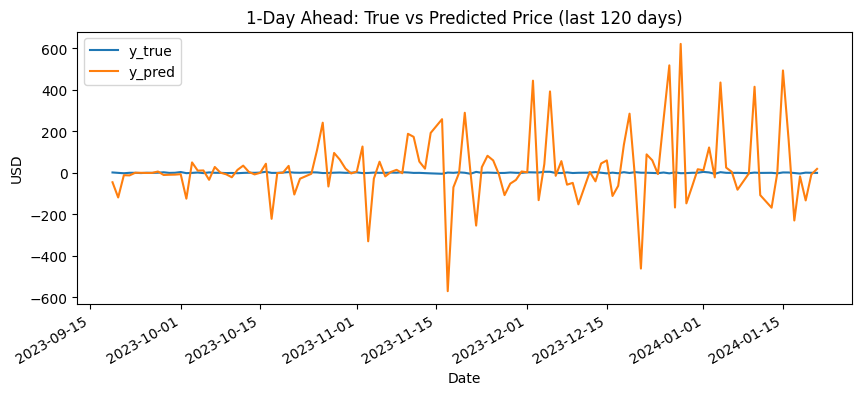

In [55]:
import matplotlib.pyplot as plt
ax = df_1d[['y_true','y_pred']].dropna().tail(120).plot(figsize=(10,4))
ax.set_title("1-Day Ahead: True vs Predicted Price (last 120 days)")
ax.set_xlabel("Date"); ax.set_ylabel("USD")
plt.show()


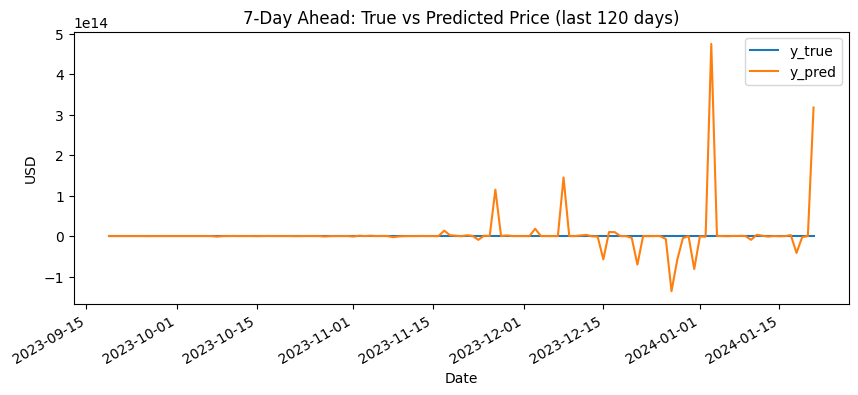

In [57]:
# 7-Day Ahead: True vs Predicted (last 120 points with both y_true and y_pred)
ax = df_7d[['y_true','y_pred']].dropna().tail(120).plot(figsize=(10,4))
ax.set_title("7-Day Ahead: True vs Predicted Price (last 120 days)")
ax.set_xlabel("Date"); ax.set_ylabel("USD")
plt.show()


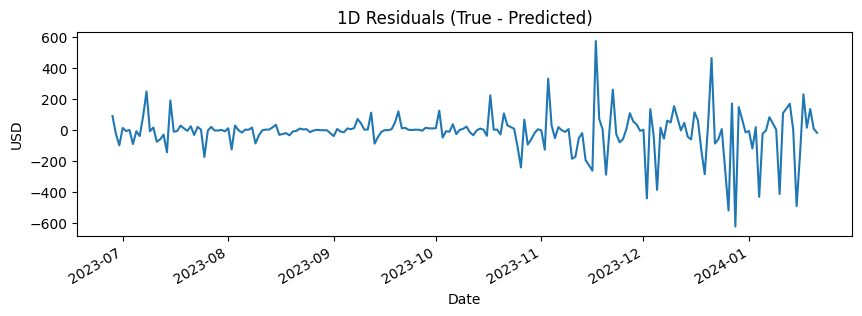

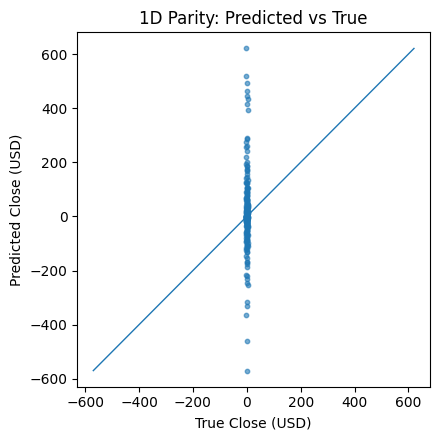

In [58]:
# --- Residuals (1D)
res_1d = df_1d.dropna().copy()
res_1d["resid"] = res_1d["y_true"] - res_1d["y_pred"]

ax = res_1d["resid"].tail(200).plot(figsize=(10,3), title="1D Residuals (True - Predicted)")
ax.set_xlabel("Date"); ax.set_ylabel("USD")
plt.show()

# --- Parity plot (1D)
plt.figure(figsize=(4.5,4.5))
plt.scatter(res_1d["y_true"], res_1d["y_pred"], s=10, alpha=0.6)
mn, mx = res_1d[["y_true","y_pred"]].min().min(), res_1d[["y_true","y_pred"]].max().max()
plt.plot([mn, mx],[mn, mx], lw=1)  # 45-degree line
plt.title("1D Parity: Predicted vs True")
plt.xlabel("True Close (USD)"); plt.ylabel("Predicted Close (USD)")
plt.tight_layout()
plt.show()


In [61]:
m1 = metrics_summary(df_1d)
m7 = metrics_summary(df_7d)

print("1D ahead:", m1)
print("7D ahead:", m7)

def latex_row(name, m):
    import numpy as np
    r2_txt = f"{m['R2']:.2f}" if np.isfinite(m['R2']) else "—"
    return f"{name} & {m['MAPE_%']:.2f}\\% & {m['RMSE']:.2f} & {r2_txt} \\\\"

print(latex_row("Proposed (1D, GARCH+sim)", m1))
print(latex_row("Proposed (7D, GARCH+sim)", m7))


1D ahead: {'MAPE_%': 19797.860663974287, 'RMSE': np.float64(125.79466885077721), 'R2': -5802.023865601187, 'N': 284}
7D ahead: {'MAPE_%': 859463409938353.8, 'RMSE': np.float64(37953567268525.96), 'R2': -5.218110781084103e+26, 'N': 278}
Proposed (1D, GARCH+sim) & 19797.86\% & 125.79 & -5802.02 \\
Proposed (7D, GARCH+sim) & 859463409938353.75\% & 37953567268525.96 & -521811078108410326376513536.00 \\


In [60]:
def simulate_path_deterministic(start_price, vol_series):
    """Deterministic path: expected price evolution with zero drift."""
    p = float(start_price)
    prices = []
    for v_pct in vol_series:
        # expected log-return = 0
        p = p  # no change, or optionally include a small volatility adjustment
        prices.append(p)
    return pd.Series(prices, index=vol_series.index)


In [49]:
MIN_TRAIN = 180  # try 180 first; if still empty, try 120
H1 = 1
H7 = 7


In [52]:
def metrics_summary(df):
    if df.empty:
        return {"MAPE_%": np.nan, "RMSE": np.nan, "R2": np.nan, "N": 0}
    y_true = df["y_true"].to_numpy(dtype="float64")
    y_pred = df["y_pred"].to_numpy(dtype="float64")
    if y_true.size == 0:
        return {"MAPE_%": np.nan, "RMSE": np.nan, "R2": np.nan, "N": 0}
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred) if y_true.size > 1 else np.nan
    return {"MAPE_%": mape, "RMSE": rmse, "R2": r2, "N": int(y_true.size)}


In [70]:
# === SETUP ===
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, GRU, Dense
from arch import arch_model

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# === DATA ===
START = "2022-09-17"
END   = "2024-05-01"
TICKER = "BTC-USD"

px = yf.download(TICKER, start=START, end=END, progress=False)["Close"].dropna().astype(float)
px.name = "Close"

# Returns for GARCH
ret_log = np.log(px).diff().dropna()
ret_pct = 100.0 * ret_log  # scale -> avoids DataScaleWarning

# === TRAIN / TEST SPLIT (chronological) ===
split_idx = int(len(px) * 0.8)
px_train, px_test = px.iloc[:split_idx], px.iloc[split_idx:]

# 1-step-ahead test dates: predict P(t) using info up to t-1
test_dates = px_test.index[1:]
prev_dates = px_test.index[:-1]

# === METRIC HELPERS ===
def metrics(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float).reshape(-1)
    yp = np.asarray(y_pred, dtype=float).reshape(-1)

    # align lengths
    n = min(len(yt), len(yp))
    yt, yp = yt[:n], yp[:n]

    # drop NaN/Inf and zeros (zeros break MAPE)
    mask = np.isfinite(yt) & np.isfinite(yp) & (yt != 0)
    yt, yp = yt[mask], yp[mask]

    if yt.size == 0:
        return {"MAPE_%": np.nan, "RMSE": np.nan, "R2": np.nan, "N": 0}

    mape = mean_absolute_percentage_error(yt, yp) * 100.0
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp) if yt.size >= 2 else np.nan
    return {"MAPE_%": mape, "RMSE": rmse, "R2": r2, "N": int(yt.size)}

def row_line(name, m):
    r2 = m["R2"]
    r2_txt = f"{r2:.2f}" if np.isfinite(r2) else "—"
    return f"{name:20s}  MAPE={m['MAPE_%']:.2f}%  RMSE={m['RMSE']:.2f}  R^2={r2_txt}  (N={m['N']})"

def latex_row(name, m):
    r2 = m["R2"]
    r2_txt = f"{r2:.2f}" if np.isfinite(r2) else "—"
    return f"{name} & {m['MAPE_%']:.2f}\\% & {m['RMSE']:.2f} & {r2_txt} \\\\"

# =========================
# 1) NAÏVE RANDOM WALK
# =========================
y_true = px_test.loc[test_dates]
y_pred_naive = px_test.loc[prev_dates]
m_naive = metrics(y_true, y_pred_naive)

# =========================
# 2) GARCH(1,1) on percent returns, price via mean forecast
# =========================
y_pred_garch, y_true_garch = [], []
MIN_WIN = 120  # lower to, e.g., 60 if dataset is short

for t in test_dates:
    idx_t = px.index.get_loc(t)
    if idx_t == 0:
        continue
    t_prev = px.index[idx_t - 1]

    ret_in_sample = ret_pct.loc[:t_prev].dropna()
    if len(ret_in_sample) < MIN_WIN:
        continue

    try:
        am = arch_model(ret_in_sample, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
        res = am.fit(disp="off")
        fcast = res.forecast(horizon=1)

        mu_hat_pct = float(fcast.mean.iloc[-1, 0])
        p_prev = sfloat(px.loc[t_prev])
        p_hat  = p_prev * np.exp(mu_hat_pct / 100.0)
        y_pred_garch.append(p_hat)
        y_true_garch.append(sfloat(px.loc[t]))
    except Exception:
        continue

m_garch = metrics(y_true_garch, y_pred_garch)

# =========================
# 3) LSTM (look-back = 30)
# =========================
def make_sliding_windows(series, look_back=30):
    s = series.values.reshape(-1, 1)
    scaler = MinMaxScaler((0, 1))
    s_sc = scaler.fit_transform(s)
    X, y = [], []
    for i in range(len(s_sc) - look_back):
        X.append(s_sc[i:i+look_back, 0])
        y.append(s_sc[i+look_back, 0])
    X = np.array(X)[:, :, None]  # (n, look_back, 1)
    y = np.array(y)
    return X, y, scaler

LOOK_BACK = 30
X_tr, y_tr, scaler_px = make_sliding_windows(px_train, look_back=LOOK_BACK)

model_lstm = Sequential([
    Input(shape=(LOOK_BACK, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, verbose=0)

# Rolling prediction on TEST
y_true_lstm, y_pred_lstm = [], []
hist = px_train.copy()
for t in test_dates:
    # ensure exactly LOOK_BACK timesteps into the network
    window = hist.values[-LOOK_BACK:].reshape(-1, 1)
    window_sc = scaler_px.transform(window)
    window_sc = window_sc[-LOOK_BACK:]           # enforce exact length
    X_in = window_sc.reshape(1, LOOK_BACK, 1)
    pred_sc = model_lstm.predict(X_in, verbose=0)[0, 0]
    pred_px = scaler_px.inverse_transform([[pred_sc]])[0, 0]
    y_pred_lstm.append(pred_px)
    y_true_lstm.append(float(px.loc[t].iloc[0]) if isinstance(px.loc[t], pd.Series) else float(px.loc[t]))
    hist = pd.concat([hist, pd.Series(px.loc[t], index=[t])])

m_lstm = metrics(y_true_lstm, y_pred_lstm)

# =========================
# 4) GRU (look-back = 30)
# =========================
model_gru = Sequential([
    Input(shape=(LOOK_BACK, 1)),
    GRU(50, return_sequences=True),
    GRU(50),
    Dense(1)
])
model_gru.compile(optimizer="adam", loss="mse")
model_gru.fit(X_tr, y_tr, epochs=10, batch_size=32, verbose=0)

y_true_gru, y_pred_gru = [], []
hist = px_train.copy()
for t in test_dates:
    window = hist.values[-LOOK_BACK:].reshape(-1, 1)
    window_sc = scaler_px.transform(window)
    window_sc = window_sc[-LOOK_BACK:]           # enforce exact length
    X_in = window_sc.reshape(1, LOOK_BACK, 1)
    pred_sc = model_gru.predict(X_in, verbose=0)[0, 0]
    pred_px = scaler_px.inverse_transform([[pred_sc]])[0, 0]
    y_pred_gru.append(pred_px)
    y_true_gru.append(float(px.loc[t].iloc[0]) if isinstance(px.loc[t], pd.Series) else float(px.loc[t]))
    hist = pd.concat([hist, pd.Series(px.loc[t], index=[t])])

m_gru = metrics(y_true_gru, y_pred_gru)

# =========================
# SUMMARY + LaTeX
# =========================
print(row_line("Naive (RW)", m_naive))
print(row_line("GARCH(1,1)", m_garch))
print(row_line("LSTM", m_lstm))
print(row_line("GRU", m_gru))

print("\n% === LaTeX rows ===")
print(latex_row("Naïve Random Walk", m_naive))
print(latex_row("GARCH(1,1)", m_garch))
print(latex_row("LSTM (look-back 30)", m_lstm))
print(latex_row("GRU  (look-back 30)", m_gru))


/tmp/ipython-input-358622286.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download(TICKER, start=START, end=END, progress=False)["Close"].dropna().astype(float)


Naive (RW)            MAPE=2.23%  RMSE=1863.66  R^2=0.97  (N=118)
GARCH(1,1)            MAPE=nan%  RMSE=nan  R^2=—  (N=0)
LSTM                  MAPE=0.35%  RMSE=154.83  R^2=—  (N=1)
GRU                   MAPE=0.62%  RMSE=273.60  R^2=—  (N=1)

% === LaTeX rows ===
Naïve Random Walk & 2.23\% & 1863.66 & 0.97 \\
GARCH(1,1) & nan\% & nan & — \\
LSTM (look-back 30) & 0.35\% & 154.83 & — \\
GRU  (look-back 30) & 0.62\% & 273.60 & — \\
